Image Dimensions: (452, 678, 3)
Number of Channels: 3


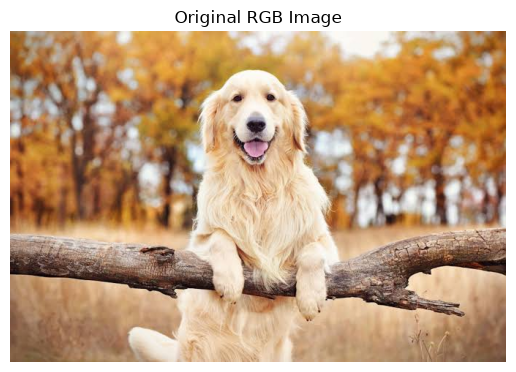

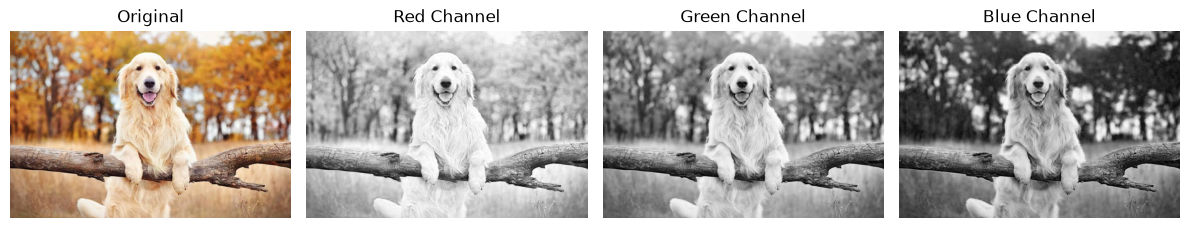

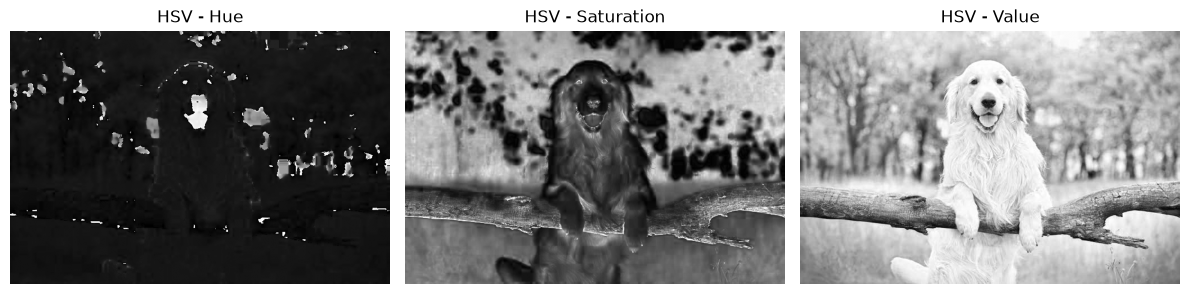

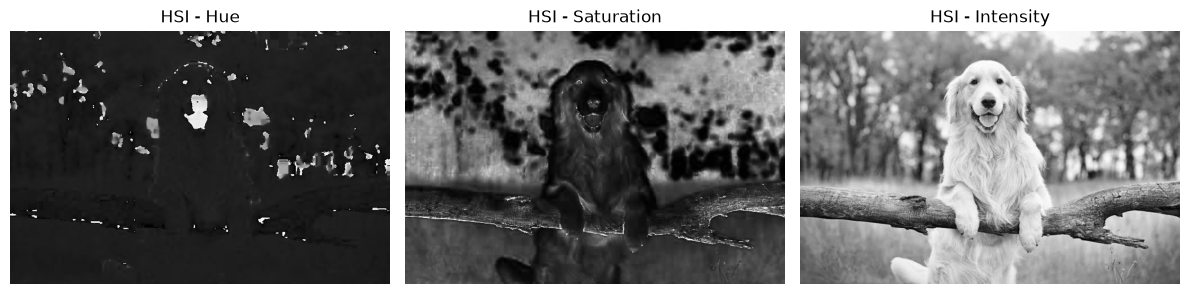

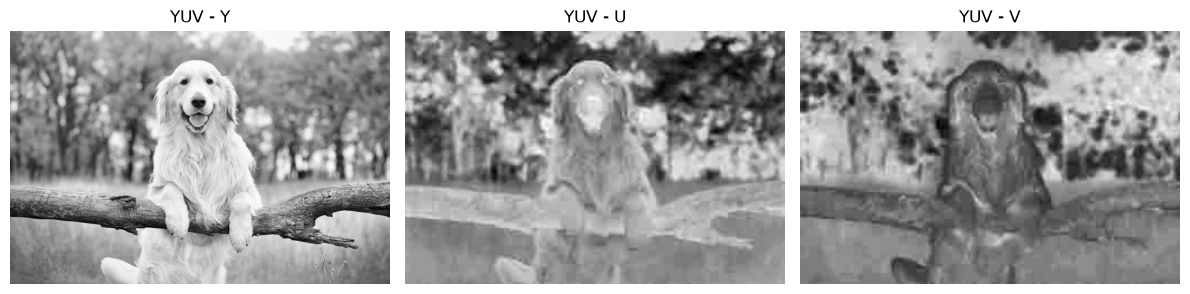

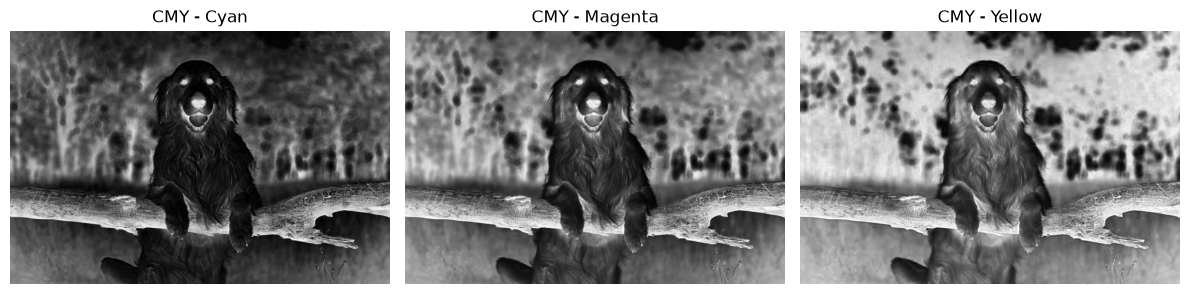

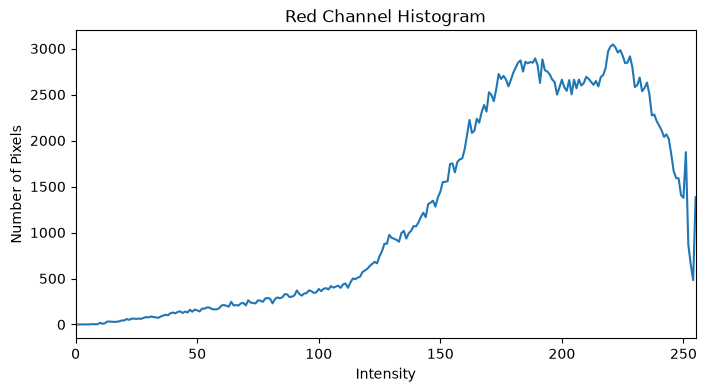

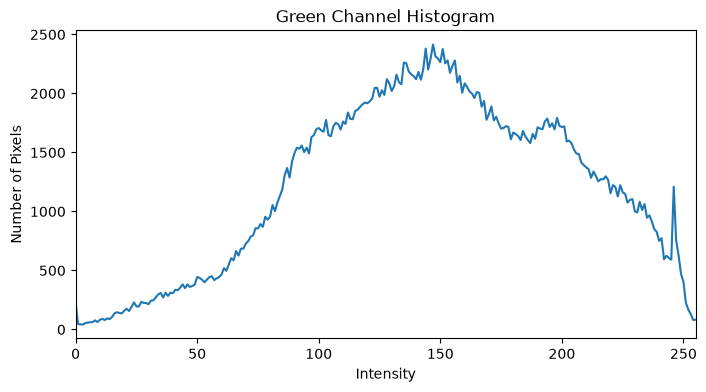

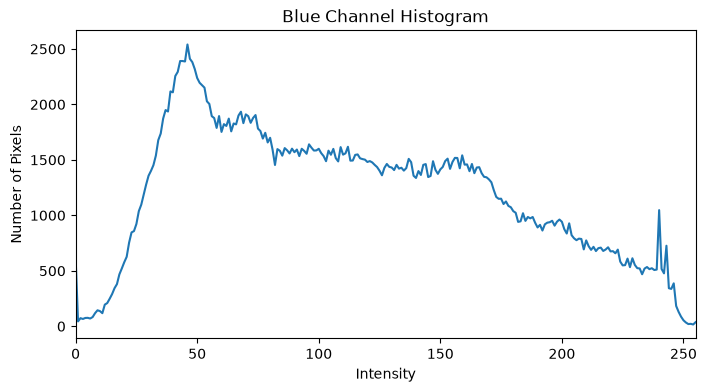

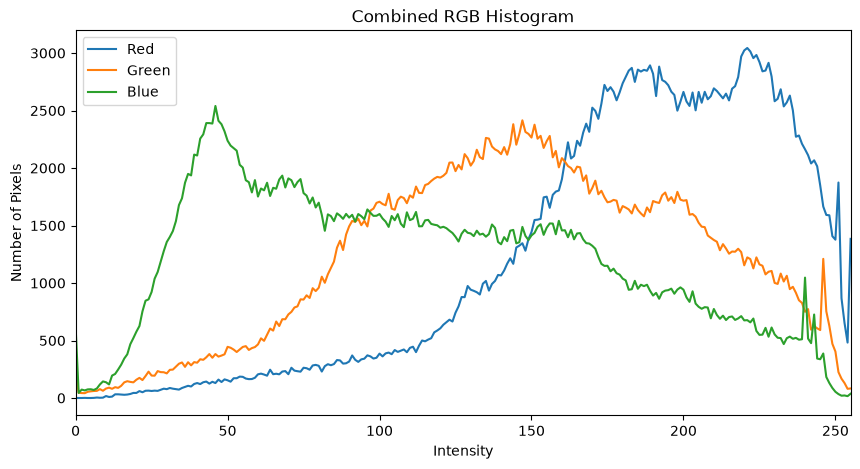

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("../images/golden.jpeg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Image Dimensions:", image.shape)
print("Number of Channels:", image.shape[2])

plt.imshow(image)
plt.title("Original RGB Image")
plt.axis("off")
plt.show()


R = image[:, :, 0]
G = image[:, :, 1]
B = image[:, :, 2]

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(R, cmap="gray")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(G, cmap="gray")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(B, cmap="gray")
plt.title("Blue Channel")
plt.axis("off")

plt.tight_layout()
plt.show()


hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

H = hsv[:, :, 0]
S = hsv[:, :, 1]
V = hsv[:, :, 2]

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap="gray")
plt.title("HSV - Hue")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(S, cmap="gray")
plt.title("HSV - Saturation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(V, cmap="gray")
plt.title("HSV - Value")
plt.axis("off")

plt.tight_layout()
plt.show()


rgb = image.astype(np.float64) / 255.0

R_norm = rgb[:, :, 0]
G_norm = rgb[:, :, 1]
B_norm = rgb[:, :, 2]

minimum = np.minimum(
    np.minimum(R_norm, G_norm),
    B_norm
)

maximum = np.maximum(
    np.maximum(R_norm, G_norm),
    B_norm
)

delta = maximum - minimum

I = (R_norm + G_norm + B_norm) / 3

S_hsi = np.zeros_like(I)

mask = I > 0

S_hsi[mask] = 1 - (
    minimum[mask] / I[mask]
)

H_hsi = np.zeros_like(I)

mask = delta != 0

H_hsi[mask] = np.arccos(
    np.clip(
        0.5 * (
            (R_norm[mask] - G_norm[mask]) +
            (R_norm[mask] - B_norm[mask])
        ) / delta[mask],
        -1,
        1
    )
)

H_hsi[B_norm > G_norm] = (
    2 * np.pi -
    H_hsi[B_norm > G_norm]
)

H_hsi = H_hsi / (2 * np.pi)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(H_hsi, cmap="gray")
plt.title("HSI - Hue")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(S_hsi, cmap="gray")
plt.title("HSI - Saturation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(I, cmap="gray")
plt.title("HSI - Intensity")
plt.axis("off")

plt.tight_layout()
plt.show()


yuv = cv2.cvtColor(image, cv2.COLOR_RGB2YUV)

Y = yuv[:, :, 0]
U = yuv[:, :, 1]
V_yuv = yuv[:, :, 2]

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(Y, cmap="gray")
plt.title("YUV - Y")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(U, cmap="gray")
plt.title("YUV - U")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(V_yuv, cmap="gray")
plt.title("YUV - V")
plt.axis("off")

plt.tight_layout()
plt.show()


C = 1 - R_norm
M = 1 - G_norm
Y_cmy = 1 - B_norm

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(C, cmap="gray")
plt.title("CMY - Cyan")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(M, cmap="gray")
plt.title("CMY - Magenta")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(Y_cmy, cmap="gray")
plt.title("CMY - Yellow")
plt.axis("off")

plt.tight_layout()
plt.show()


hist_R = np.bincount(R.flatten(), minlength=256)
hist_G = np.bincount(G.flatten(), minlength=256)
hist_B = np.bincount(B.flatten(), minlength=256)

plt.figure(figsize=(8, 4))
plt.plot(hist_R)
plt.title("Red Channel Histogram")
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.xlim(0, 255)
plt.show()


plt.figure(figsize=(8, 4))
plt.plot(hist_G)
plt.title("Green Channel Histogram")
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.xlim(0, 255)
plt.show()


plt.figure(figsize=(8, 4))
plt.plot(hist_B)
plt.title("Blue Channel Histogram")
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.xlim(0, 255)
plt.show()


plt.figure(figsize=(10, 5))

plt.plot(hist_R, label="Red")
plt.plot(hist_G, label="Green")
plt.plot(hist_B, label="Blue")

plt.title("Combined RGB Histogram")
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.xlim(0, 255)
plt.legend()

plt.show()

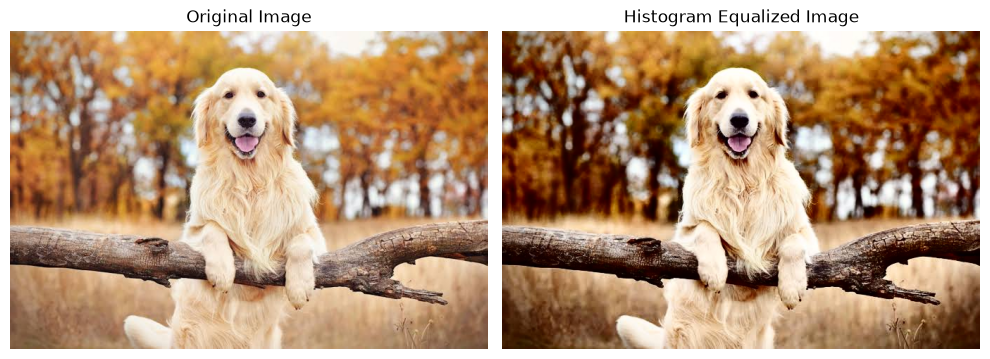

In [1]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("../images/golden.jpeg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

yuv = cv2.cvtColor(image, cv2.COLOR_RGB2YUV)

yuv[:, :, 0] = cv2.equalizeHist(yuv[:, :, 0])

equalized = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(equalized)
plt.title("Histogram Equalized Image")
plt.axis("off")

plt.tight_layout()
plt.show()